In [1]:
using Pkg
Pkg.add("Combinatorics")
Pkg.add("Distributions")
Pkg.add("Bits")
Pkg.add("Random")
Pkg.add("Parsers")
Pkg.add("LinearAlgebra")
Pkg.add("DataFrames", io=devnull)
Pkg.add("Plots", io=devnull)
Pkg.add("Measures", io=devnull)

using LinearAlgebra
using Distributions
using Random
using Bits
using Parsers
using DataFrames
using Plots, Measures

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.8/Project.toml`
  No Changes to `~/.julia/environments/v1.8/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.8/Project.toml`
  No Changes to `~/.julia/environments/v1.8/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.8/Project.toml`
  No Changes to `~/.julia/environments/v1.8/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.8/Project.toml`
  No Changes to `~/.julia/environments/v1.8/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.8/Project.toml`
  No Changes to `~/.julia/environments/v1.8/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.8/Project.toml`
  No Changes to `~/.julia/environments/v1.8/Manifest.toml`


1. Generate Random starting points.
2. Get individual from starting points.
3. Get starting points from individual.
4. Check if starting points are within acceptable range.

In [27]:
# Random Starting point generator k - length of motif, t is number of sequences
function RandomGenerator(DnaSequenceLength, k, t)
    randomStartPoints = Vector{Int16}(undef, 0)
    for i in range(1, t)
        push!(randomStartPoints, ceil(Int, rand()*(DnaSequenceLength - k + 1)))
    end
    return randomStartPoints
end

# represent each starting point as 16 bits and concat them together and return
function getIndividual(randomStartingPoints)
    result = ""
    for i in randomStartingPoints
        temp = string(bits(Int16(i)))
        temp = replace(temp, "<" => "")
        temp = replace(temp, ">" => "")
        temp =replace(temp, " " => "")
        result *= temp
    end
    return result
end

# get numericIndividual from the individual
function getNumericIndividual(regularIndividual)
    result = []
    numIndividuals = Int(length(regularIndividual)/16)
    for i in range(0, numIndividuals-1)
        temp = regularIndividual[Int(16*i+1):Int(16*i+16)]
        push!(result, parse(Int64, temp; base=2))
    end
    return result
    
end


# check if starting points are valid in numeric Individual
function validateIndividual(regularIndividual, DnaSequences, k)
    numericIndividual = getNumericIndividual(regularIndividual)
    for i in range(1, length(numericIndividual))
        if numericIndividual[i] > length(DnaSequences[1]) - k + 1
            return false
        end
    end
    return true
end

validateIndividual (generic function with 1 method)

1. Get Fitness score of a set of motifs for a set of starting points.

In [28]:
# pseudo count for each nucelotide is 1 and sum of pseudo counts = 4(1) = 4
function getFitnessScore(motifs, k, t)
    ScorerDict = Dict([
        ("A", zeros(k)),
        ("C", zeros(k)),
        ("G", zeros(k)),
        ("T", zeros(k))
    ])
    #println(motifs)
    S = 0
    # A, C, G, T order 
    bgCount = Dict([
        ("A", 0),
        ("C", 0),
        ("G", 0),
        ("T", 0)            
    ])
    for col in range(1, k)
        for row in range(1, t)
            ScorerDict[string(motifs[row][col])][col] += 1
            S += 1
            bgCount[string(motifs[row][col])] += 1
        end
    end

    fitness = 0
    for col in range(1, k)
        informationContent = 0
        for nuc in ["A", "C", "T", "G"]
            freqObs = (ScorerDict[nuc][col] + 1)/(t - 1 + 4)
            freqBg = (bgCount[nuc] + 1)/(S + 4)
            informationContent += freqObs*(log(2, (freqObs/freqBg)))
        end
        fitness += informationContent
    end

    return fitness
end

getFitnessScore (generic function with 1 method)

1. perform crossover.
2. perform mutation.
3. perform selection - returns indices of selected individuals - roulette wheel selection based on their fitness scores

In [29]:
# get 2 bit strings and output 2 offspring bit strings
function performCrossover(parent1, parent2)
    
    crossPosition = Int(ceil(rand()*length(parent1)))
    #println(crossPosition)
    
    offspring1 = parent1[1:crossPosition]*parent2[crossPosition+1:end]
    offspring2 = parent1[crossPosition+1:end]*parent2[1:crossPosition]
    
    return offspring1, offspring2
end

# get 1 bit string and output 1 mutated bit string
function performMutation(regularIndividual, mutationRate, mutationProb, k)
    
    for i in range(1, mutationRate)
        mutPosition = Int(ceil(rand()*(length(regularIndividual) - k + 1)))
        #println(mutPosition)
        currProb = rand()
        #println(currProb)
        temp = '0'
        if(currProb <= mutationProb)
            # perform mutation on that random bit
            if(regularIndividual[mutPosition] == '1')
                temp = '0'
            else
                temp = '1'
            end
            if mutPosition == 1
                return temp*regularIndividual[2:end]
            else
                return regularIndividual[1:mutPosition-1]*temp*regularIndividual[mutPosition+1:end]
            end
        end 
    end
    
    return regularIndividual
end

# roulette wheel selection operation 
function performSelection(numSelections, fitnessScores)
    
    normalizedFitnessScores = normalize(fitnessScores)
    individualIndices = []
    for i in range(1, length(fitnessScores))
        push!(individualIndices, i)
    end
    selectedIndices = wsample(individualIndices, normalizedFitnessScores, numSelections, replace = false)
    
    return selectedIndices
end

performSelection (generic function with 1 method)

In [30]:
function consensusMotif(bestMotifs)
    
    consensusDict = Dict([
        ("A", zeros(length(bestMotifs[1]))),
        ("C", zeros(length(bestMotifs[1]))),
        ("G", zeros(length(bestMotifs[1]))),
        ("T", zeros(length(bestMotifs[1])))
    ])
    
    for i in range(1, length(bestMotifs[1]))
        for motif in bestMotifs
            consensusDict[string(motif[i:i])][i] += 1
        end
    end
        
    consensusMotif = ""
    for i in range(1, length(bestMotifs[1]))
        maxCount = 0
        currNuc = ""
        if consensusDict["A"][i] > maxCount
            maxCount = consensusDict["A"][i]
            currNuc = "A"
        end
        if consensusDict["C"][i] > maxCount
            maxCount = consensusDict["C"][i]
            currNuc = "C"
        end
        if consensusDict["G"][i] > maxCount
            maxCount = consensusDict["G"][i]
            currNuc = "G"
        end
        if consensusDict["T"][i] > maxCount
            maxCount = consensusDict["T"][i]
            currNuc = "T"
        end
        consensusMotif *= currNuc
    end
    return consensusMotif
end

consensusMotif (generic function with 1 method)

In [31]:
# using shift width to evaluate all "possible" candidates in proximity
# motif width k and number of sequences t 
function evaluateCandidate(DnaSequences, numericIndividual, shiftWidth, k, t)
    maxFitness = 0
    bestWidth = 0
    motifs = []
    #println(numericIndividual) 
    #println(DnaSequences)
    for i in range(-shiftWidth, shiftWidth)
        #print(i)
        # get motifs based on starting positions in individual
        for j in range(1, t)
            if numericIndividual[j] + i < 1 || numericIndividual[j] + i > length(DnaSequences[1]) - k + 1
                motifs = []
                break
            end
            push!(motifs, DnaSequences[j][numericIndividual[j] + i:numericIndividual[j] + i + k - 1])
        end
        if length(motifs) != 0 
            currFitness = getFitnessScore(motifs, k, t)
            #println(i, currFitness, motifs)
            if(currFitness > maxFitness)
                maxFitness = currFitness
                bestWidth = i
            end
            motifs = []
        end
    end
    
    # return the updatedIndividual and its fitness score
    updatedIndividual = []
    for i in range(1, t)
        push!(updatedIndividual, numericIndividual[i] + bestWidth)
    end
    return updatedIndividual, maxFitness
end

evaluateCandidate (generic function with 1 method)

In [32]:
function AddMutation(m)
    Nuc = ["A", "G", "T", "C"]
    Nmutations = 0
    mutated = m
    # introducing mutations in the motif 
    for j in range(1, Nmutations)
        randomIndex = Int(ceil(rand()*length(m)))
        if randomIndex == 1
            mutated = Nuc[Int(ceil(rand()*4))] * m[2:length(m)]
        elseif randomIndex == length(m)
            mutated = m[1:(length(m)-1)] * Nuc[Int(ceil(rand()*4))]
        else
            mutated = m[1:randomIndex-1] * Nuc[Int(ceil(rand()*4))] * m[randomIndex+1:length(m)]
        end
    end    
    
    return mutated
end


function DnaGenerator(t, m, l)
    DnaSequences = []
    GC = ["G", "C"]
    AT = ["A", "T"]
    lengthExceptMotif = l - length(m)
    baseSequence = ""
    # Generating Dna Sequences, apart from the motif, with 41% GC content
    for i in range(1, ceil(0.41 * lengthExceptMotif))
        baseSequence *= GC[ceil(Int, rand()*2)]
    end
    # Generating Dna Sequences, apart from the motif, with remaining % of AT content
    for i in range(1, lengthExceptMotif - ceil(0.41 * lengthExceptMotif))
        baseSequence *= AT[ceil(Int, rand()*2)]
    end
    
    mutatedMotifs = []
    
    # introducing a different mutation in each motif to be implanted.
    for i in range(1, t)
        push!(mutatedMotifs, AddMutation(m))
    end
    
    #println(mutatedMotifs)
    actualStartPositions = []
    # adding the motif to each randomly generated sequence
    for i in range(1, t)
        permSequence = join(collect(baseSequence)[randperm(length(baseSequence))])

        insertAt = ceil(Int, rand()*(lengthExceptMotif+1))
        push!(actualStartPositions, insertAt)
        if insertAt == 1
            endSequence = mutatedMotifs[i] * permSequence
        elseif insertAt == lengthExceptMotif + 1
            endSequence = permSequence * mutatedMotifs[i]
        else
            endSequence = permSequence[1:insertAt-1] * mutatedMotifs[i] * permSequence[insertAt:lengthExceptMotif]
        end
        push!(DnaSequences, endSequence)
    end
    return DnaSequences, actualStartPositions
end

DnaGenerator (generic function with 1 method)

### Running MDGA
**Inputs**
1. DNA sequences
2. Motif length(width)
3. g times
4. option_print(true/false)

**Outputs**
1. Start position
2. Fitness score

In [41]:
function Execute_MDGA(dna_seqs, width, g_times, option_print)
    # set motif width 
    k = width
    # set sequence length 
    l = length(dna_seqs[1])
    # set number of sequences 
    t = length(dna_seqs)
    # set crossover probability 
    crossProb = 1
    # set mutation rate
    mutationRate = 1
    # set mutation probability
    mutationProb = 0.01
    # set shiftWidth 
    shiftWidth = 5
    # repeat experiment g times
    g = g_times
    # set population size 
    popSize = 100
    
    # generate DNA sequences with the motif implanted in them at random positions
    DnaSequences = dna_seqs
    #DnaSequences, actualStartPositions = DnaGenerator(t, "ACTGACTGACTGACTGACTG", l)

    # generate first population of individuals - 4 individuals(Test)
    numericIndividuals = []
    regularIndividuals = []

    for i in range(1, popSize)
        # generate a set of random starting points
        numericIndividual = RandomGenerator(l, k, t)
        push!(numericIndividuals, numericIndividual)
        # get the corresponding individual 
        regularIndividual = getIndividual(numericIndividual)
        push!(regularIndividuals, regularIndividual)
    end
    
    #println(numericIndividuals)
    #println(regularIndividuals)
    # evaluate current individuals in population - with shift width and get their best scores
    fitnessScores = []
    for i in range(1, popSize)
        updatedIndividual, fitnessScore = evaluateCandidate(DnaSequences, numericIndividuals[i], shiftWidth, k, t)
        #println(updatedIndividual)
        #println(fitnessScore)
        push!(fitnessScores, fitnessScore)
        numericIndividuals[i] = updatedIndividual
        regularIndividuals[i] = getIndividual(updatedIndividual)
    end
    
    #println(fitnessScores)
    
    # iterations begin    
    for i in range(1, g)
        #print("iteration ")
        #println(i)
        # select 50 parents from the population
        selectedIndices = performSelection(Int(popSize/2), fitnessScores)
        childCount = 0
        # for each pair perform crossover and mutation
        for j in range(1, length(selectedIndices), step=2)
            currCrossProb = rand()
            if currCrossProb <= crossProb

                parent1 = regularIndividuals[selectedIndices[Int(j)]]
                parent2 = regularIndividuals[selectedIndices[Int(j)+1]]
                # perform crossover
                offspring1, offspring2 = performCrossover(parent1, parent2)
                # perform mutation
                mutatedIndividual1 = performMutation(offspring1, mutationRate, mutationProb, k)
                mutatedIndividual2 = performMutation(offspring2, mutationRate, mutationProb, k)  

                if validateIndividual(mutatedIndividual1, DnaSequences, k)
                    mutatedNumericIndividual1 = getNumericIndividual(mutatedIndividual1)
                    # evaluate child1
                    updatedMutatedNumericIndividual1, fitnessScore = evaluateCandidate(DnaSequences, mutatedNumericIndividual1, shiftWidth, k, t)
                    push!(regularIndividuals, mutatedIndividual1)
                    push!(fitnessScores, fitnessScore)
                    push!(numericIndividuals, updatedMutatedNumericIndividual1)
                    childCount += 1
                end
                if validateIndividual(mutatedIndividual2, DnaSequences, k)
                    mutatedNumericIndividual2 = getNumericIndividual(mutatedIndividual2)
                    # evaluate child2
                    updatedMutatedNumericIndividual2, fitnessScore = evaluateCandidate(DnaSequences, mutatedNumericIndividual2, shiftWidth, k, t)
                    push!(regularIndividuals, mutatedIndividual2)
                    push!(fitnessScores, fitnessScore)
                    push!(numericIndividuals, updatedMutatedNumericIndividual2)
                    childCount += 1
                end
            end
        end

        
        #println(childCount)

        # remove the worst performing ones
        sortHelper = sortperm(fitnessScores, rev = true)
        
        fitnessScores = fitnessScores[sortHelper]
        numericIndividuals = numericIndividuals[sortHelper]
        regularIndividuals = regularIndividuals[sortHelper]
        #println(regularIndividuals)
        # change 4 to number of individuals in population
        fitnessScores = fitnessScores[1:popSize]
        numericIndividuals = numericIndividuals[1:popSize]
        regularIndividuals = regularIndividuals[1:popSize]
    end
    
    bestMotifs = []
    
    for i in range(1, length(numericIndividuals[1]))
        push!(bestMotifs, DnaSequences[i][numericIndividuals[1][i]:numericIndividuals[1][i] + k - 1]) 
    end
    bestMotif = consensusMotif(bestMotifs)
    
    if option_print == true 
        print("consensus Motif ")
        println(bestMotif)
        #print("actual start positions of motif ")
        #println(actualStartPositions)
        print("predicted start positions of motif ")
        println(numericIndividuals[1])
        println("fitness score ", fitnessScores[1])
    end
    return numericIndividuals[1], fitnessScores[1], bestMotif
            
end

Execute_MDGA (generic function with 1 method)

# Dummy Data

1. Dumma data perfect
    * Consensus motif: AAAATTTTAAAATTTT
    * start positions: [64,39,80,93,35,27,33,42,96,44,19,26,9,97,87]



In [147]:
# Read a text file
test = open("/Users/sangmi_jeong/Documents/julia/dummy_data_perfect.txt", "r")
lines = readlines(test)
close(test)

l = length(lines)
for i in 1:l
    lines[i] = strip(lines[i])
end

width = parse(Int64, match(r"^(\d+)", lines[1], 1)[1]) # 
t = parse(Int64, match(r"(\d+)$", lines[1], 2)[1])
dna_seqs = lines[2:l];

In [148]:
# Result
best_score = []
best_motifs = []
consensus_motif = []
for i in 1:200
    start_pos, score, consensus = Execute_MDGA(dna_seqs, width, 300, true)
    push!(best_score, float(score))
    if float(score) == maximum(best_score) 
        best_motifs = start_pos
        consensus_motif = consensus
    end
end
println("\n")
println("Actual Consensus Motif: AAAATTTTAAAATTTT")
println("Start Positions of Actual Motifs: [64, 39, 80, 93, 35, 27, 33, 42, 96, 44, 19, 26, 9, 97, 87]", "\n")

println("Predicted Consensus Motif: ", consensus_motif)
println("Start Positions of Predicted Motifs: ", best_motifs)
println("Best Predicted Motifs: ")
for l in 1:t
    start_l = Int16(best_motifs[l])
    println(" ", l,": Motif  = ", dna_seqs[l][start_l:start_l+width-1])
end

consensus Motif AAAATTTTAAAATTTT
predicted start positions of motif Any[96, 78, 55, 49, 19, 76, 96, 95, 58, 27, 28, 93, 88, 39, 112]
fitness score 7.263791730431408
consensus Motif GAATTCTTACACAGCT
predicted start positions of motif Any[129, 35, 17, 32, 56, 26, 30, 103, 74, 109, 133, 115, 70, 127, 2]
fitness score 5.227625459980768
consensus Motif GATTCCCACATGGAGA
predicted start positions of motif Any[37, 2, 88, 123, 93, 92, 98, 15, 2, 4, 118, 131, 131, 72, 105]
fitness score 4.544932123503109
consensus Motif ACACCTATAGTATCGA
predicted start positions of motif Any[52, 128, 67, 66, 84, 127, 11, 81, 60, 87, 14, 72, 8, 60, 13]
fitness score 5.424843273546963
consensus Motif TTCTAAAATTTTGGAC
predicted start positions of motif Any[101, 130, 131, 6, 78, 48, 30, 10, 37, 109, 32, 60, 84, 43, 68]
fitness score 6.403904017893504
consensus Motif AAAAACGGTTTCGCAG
predicted start positions of motif Any[54, 61, 42, 26, 86, 77, 64, 16, 109, 77, 41, 6, 58, 100, 86]
fitness score 5.446492893438423
con

consensus Motif CTCCAGTCTCAGCAGC
predicted start positions of motif Any[53, 51, 37, 22, 90, 88, 75, 53, 23, 46, 119, 36, 62, 92, 116]
fitness score 5.33403055450541
consensus Motif TAAAAATTTTAAATTT
predicted start positions of motif Any[102, 96, 6, 40, 10, 43, 131, 61, 31, 88, 33, 92, 34, 46, 41]
fitness score 6.464383913677943
consensus Motif TAGAATTTCAAAATTT
predicted start positions of motif Any[47, 96, 16, 56, 129, 35, 23, 129, 114, 123, 26, 55, 107, 20, 49]
fitness score 5.872310944539533
consensus Motif AAATGCAAAAATTTAA
predicted start positions of motif Any[117, 98, 104, 34, 21, 71, 12, 36, 13, 20, 29, 94, 81, 73, 119]
fitness score 6.36692938174739
consensus Motif AAATTTTAAAATTTTC
predicted start positions of motif Any[103, 98, 69, 50, 18, 18, 97, 43, 42, 28, 13, 57, 115, 14, 125]
fitness score 5.723571451567845
consensus Motif TAAAGTTCAAAATTTT
predicted start positions of motif Any[48, 9, 9, 48, 19, 36, 95, 42, 71, 68, 132, 55, 15, 80, 57]
fitness score 6.035458379844352
conse

consensus Motif TTTAAAAATTGTAAAC
predicted start positions of motif Any[70, 13, 13, 54, 105, 126, 72, 48, 18, 63, 31, 98, 86, 43, 60]
fitness score 6.023722827404175
consensus Motif CCTAAATTTTAAAATT
predicted start positions of motif Any[85, 50, 130, 74, 17, 35, 53, 84, 31, 135, 17, 35, 112, 91, 54]
fitness score 6.379656338526307
consensus Motif AAATTTTCTAAGCTTG
predicted start positions of motif Any[96, 16, 46, 86, 65, 61, 37, 42, 34, 55, 132, 113, 89, 48, 42]
fitness score 5.712180707913442
consensus Motif ACCTCTCGAGTAATTC
predicted start positions of motif Any[68, 128, 31, 10, 73, 45, 10, 4, 87, 92, 59, 56, 71, 31, 66]
fitness score 6.094356283613906
consensus Motif TGAAAATTTTAAAATT
predicted start positions of motif Any[85, 95, 92, 54, 25, 99, 23, 11, 31, 120, 54, 79, 113, 11, 115]
fitness score 5.766676025096298
consensus Motif AATCTGATGGATCGCG
predicted start positions of motif Any[62, 39, 119, 12, 52, 78, 12, 67, 79, 61, 62, 16, 105, 49, 123]
fitness score 5.7612577349039285
co

consensus Motif ACGCGAGTCAACATTT
predicted start positions of motif Any[47, 29, 77, 98, 94, 80, 41, 73, 24, 18, 84, 5, 14, 91, 48]
fitness score 5.212837365334648
consensus Motif GATAAACTTCAAGGAT
predicted start positions of motif Any[111, 83, 75, 68, 79, 23, 93, 10, 119, 88, 25, 46, 78, 26, 128]
fitness score 5.24503334937558
consensus Motif GGAAAATTTTAAAATT
predicted start positions of motif Any[85, 27, 14, 39, 64, 4, 38, 40, 74, 25, 116, 129, 78, 37, 62]
fitness score 6.703256482102294
consensus Motif TTTAAAATTTTCAAAT
predicted start positions of motif Any[63, 51, 84, 46, 25, 49, 109, 48, 29, 32, 32, 77, 52, 56, 61]
fitness score 5.77839282830487
consensus Motif GTAAAATTTTAAGATT
predicted start positions of motif Any[77, 77, 15, 46, 27, 42, 8, 103, 17, 106, 11, 91, 114, 18, 13]
fitness score 5.351000861668047
consensus Motif TTTAAATTCTTAACCT
predicted start positions of motif Any[121, 102, 78, 22, 106, 57, 61, 32, 39, 106, 82, 83, 122, 101, 41]
fitness score 5.091944131106401
consen

2. Dummy Data Noisy
    * Consensus motif: AAAATTTTAAAATTTT
    * Start positions: [64,39,80,93,35,27,33,42,96,44,19,26,9,97,87]
    * 13 mutations added



In [149]:
# Read a text file
test = open("/Users/sangmi_jeong/Documents/julia/dummy_data_noisy.txt", "r")
lines = readlines(test)
close(test)

l = length(lines)
for i in 1:l
    lines[i] = strip(lines[i])
end

width = parse(Int64, match(r"^(\d+)", lines[1], 1)[1]) # 
t = parse(Int64, match(r"(\d+)$", lines[1], 2)[1])
dna_seqs = lines[2:l];

In [151]:
# Result
best_score = []
best_motifs = []
consensus_motif = []
for i in 1:200
    start_pos, score, consensus = Execute_MDGA(dna_seqs, width, 300, true)
    push!(best_score, float(score))
    if float(score) == maximum(best_score) 
        best_motifs = start_pos
        consensus_motif = consensus
    end
end
println("\n")
println("Actual Consensus Motif: AAAATTTTAAAATTTT")
println("Start Positions of Actual Motifs: [64, 39, 80, 93, 35, 27, 33, 42, 96, 44, 19, 26, 9, 97, 87]", "\n")

println("Predicted Consensus Motif: ", consensus_motif)
println("Start Positions of Predicted Motifs: ", best_motifs)
println("Best Predicted Motifs: ")
for l in 1:t
    start_l = Int16(best_motifs[l])
    println(" ", l,": Motif  = ", dna_seqs[l][start_l:start_l+width-1])
end

consensus Motif ATTTTAAAAATTTCAC
predicted start positions of motif Any[107, 100, 120, 4, 22, 28, 99, 89, 35, 64, 22, 95, 83, 50, 84]
fitness score 6.711369578976256
consensus Motif TTTTGAAACTTCGAAT
predicted start positions of motif Any[127, 50, 122, 76, 39, 106, 100, 118, 61, 134, 101, 37, 91, 2, 61]
fitness score 5.494517287210458
consensus Motif GCTTAAAATTCCAAAA
predicted start positions of motif Any[127, 13, 83, 45, 104, 135, 92, 74, 29, 127, 7, 116, 50, 59, 127]
fitness score 5.821236695802893
consensus Motif CAACAATTTGAAGATT
predicted start positions of motif Any[103, 87, 71, 23, 89, 43, 94, 40, 85, 57, 123, 63, 113, 109, 54]
fitness score 5.736170169579522
consensus Motif GACTTACGAACTGCTC
predicted start positions of motif Any[26, 119, 47, 2, 65, 101, 43, 107, 73, 92, 5, 66, 5, 57, 66]
fitness score 5.676830873286529
consensus Motif ACACCCTGTTAACGAA
predicted start positions of motif Any[31, 85, 114, 84, 2, 126, 24, 132, 94, 52, 60, 14, 96, 125, 12]
fitness score 5.342361701579

consensus Motif AAAATTTTAAAATTTT
predicted start positions of motif Any[87, 76, 9, 49, 108, 43, 103, 13, 87, 27, 35, 66, 80, 29, 133]
fitness score 6.7464534963149
consensus Motif CTAAGATTTTAAAATT
predicted start positions of motif Any[95, 43, 83, 47, 72, 99, 120, 40, 128, 33, 54, 91, 78, 19, 80]
fitness score 6.167684032119817
consensus Motif CTAAAAATTTCAAAAG
predicted start positions of motif Any[55, 122, 114, 54, 120, 108, 5, 120, 30, 24, 8, 98, 130, 53, 130]
fitness score 6.158946996216846
consensus Motif TTTTTAAAACTTTACA
predicted start positions of motif Any[99, 123, 121, 101, 111, 47, 99, 55, 60, 43, 20, 88, 42, 80, 17]
fitness score 5.375885397178982
consensus Motif CATGCACGGGCTATTA
predicted start positions of motif Any[10, 28, 114, 127, 66, 132, 52, 33, 67, 15, 78, 5, 118, 32, 10]
fitness score 5.253805796614685
consensus Motif TTAAAAATTTGACGGC
predicted start positions of motif Any[101, 103, 15, 77, 25, 115, 76, 85, 119, 89, 104, 98, 85, 84, 69]
fitness score 6.3195980438407

consensus Motif AAACTTCAAAAAGTTT
predicted start positions of motif Any[49, 98, 1, 58, 45, 37, 43, 43, 33, 16, 78, 56, 70, 57, 35]
fitness score 5.874528209143794
consensus Motif AACTCAAAAATTTAGA
predicted start positions of motif Any[135, 49, 113, 44, 117, 38, 30, 44, 80, 11, 99, 96, 64, 16, 105]
fitness score 5.545898923361864
consensus Motif TTTAAGAATTGACGCA
predicted start positions of motif Any[62, 16, 66, 110, 24, 57, 100, 132, 92, 62, 90, 36, 104, 44, 88]
fitness score 5.587716860453714
consensus Motif TGCTCGAGAATTTAAA
predicted start positions of motif Any[118, 111, 110, 108, 102, 71, 30, 74, 27, 21, 61, 59, 16, 90, 26]
fitness score 5.468912201411504
consensus Motif AATTTTACGGACTCCC
predicted start positions of motif Any[42, 107, 119, 59, 21, 67, 38, 57, 97, 2, 70, 103, 36, 81, 84]
fitness score 6.126864727686733
consensus Motif GCTTTAAACGTTTCGA
predicted start positions of motif Any[81, 10, 88, 52, 77, 115, 71, 82, 37, 106, 52, 28, 9, 24, 127]
fitness score 5.693721146639995


consensus Motif CAAAATTTTAAGAATT
predicted start positions of motif Any[56, 54, 35, 86, 18, 51, 95, 41, 85, 67, 34, 55, 13, 46, 102]
fitness score 6.7477164460285275
consensus Motif GCAAACTTAAAAAGTT
predicted start positions of motif Any[47, 36, 117, 41, 122, 35, 86, 94, 105, 67, 33, 123, 6, 102, 56]
fitness score 5.710498465265
consensus Motif AAAATTTTAAAACTCG
predicted start positions of motif Any[125, 97, 59, 49, 19, 111, 77, 52, 50, 36, 27, 113, 35, 39, 13]
fitness score 6.007473772517455
consensus Motif AAAATTGTAAAATTTT
predicted start positions of motif Any[88, 59, 131, 49, 20, 9, 111, 34, 78, 71, 13, 93, 80, 79, 56]
fitness score 6.173493511967849
consensus Motif AAAATTTTAAAACTCG
predicted start positions of motif Any[96, 97, 45, 120, 28, 110, 67, 42, 42, 36, 108, 101, 80, 22, 16]
fitness score 6.092428861184478
consensus Motif TGAAACTTTTCACTTG
predicted start positions of motif Any[130, 130, 16, 18, 5, 89, 10, 73, 40, 34, 55, 6, 35, 12, 63]
fitness score 5.955104865724062
conse

# Simulation

**Inputs**
1. DNA sequences
2. actual_motifs
3. motif length(width)
4. number of repeats


**Outputs**
1. Start positions
2. Predicted Motifs
3. Time
4. Fitness score
5. Occurance of motifs(%)
6. Accuracy(%)

In [83]:
function simul(dna_seqs, actual_motifs, motif_pos, width, rep) 
    # dna_seqs = array of DNA seqs
    # actual_motifs = arrayf of actual motifs
    # motif_pos = array of position of actual motifs in integer
    t = length(dna_seqs)
    l = length(dna_seqs[1])
    
    start_pos = fill([],rep)
    pred_motifs = fill([],rep)
    
    running_time = []
    fitness_score = []
    occurance_motifs = []
    sensitivity = []
    specificity = []
    
    for i in 1:rep
        println("repeat ", i)
        result = @timed Execute_MDGA(dna_seqs, width, 300, false)

        # 3. Time
        push!(running_time, result.time)
        
        result = result[1]
        # 4. Fitness Score
        push!(fitness_score, float(result[2]))
        
        # Prediction
        # 1. and 2.
        start_pos[i] = result[1]
        pred_motif = []
        for j in 1:t
            start_j = result[1][j]
            push!(pred_motif, dna_seqs[j][start_j:start_j+width-1])
        end
        pred_motifs[i] = pred_motif
        
        # 4. Occurance of motifs(%)
        push!(occurance_motifs, sum([pred_motif[q] in actual_motifs for q in 1:t])/t*100)
        
        # 5. Accuracy(%)
        nTP = Array{Int64}(undef, t);
        nFP = Array{Int64}(undef, t);
        nFN = Array{Int64}(undef, t);
        nTN = Array{Int64}(undef, t);
        for j in 1:t
            if abs(result[1][j] - motif_pos[j]) > width
                nTP[j] = 0
                nFN[j] = width
                nFP[j] = width
                nTN[j] = l - 2*width
            else
                if result[1][j] <= motif_pos[j]
                    nTP[j] = abs(result[1][j]+width - motif_pos[j])
                else
                    nTP[j] = abs(motif_pos[j]+width - result[1][j])
                end
                nFN[j] = width - nTP[j]
                nFP[j] = width - nTP[j]
                nTN[j] = l - nTP[j] - 2*nFN[j]
            end
        end

        push!(sensitivity, sum(nTP)/(sum(nTP)+sum(nFN)))
        push!(specificity, sum(nTN)/(sum(nTN)+sum(nFP)))
        
    end
    return start_pos, pred_motifs, running_time, fitness_score, occurance_motifs, sensitivity, specificity
end

simul (generic function with 1 method)

### Read files

In [74]:
function read_files(test)
   # Read DNA Sequences: seqs
    filename = "/Users/sangmi_jeong/Documents/julia/" * test * ".fasta"
    file = open(filename, "r")
    lines = readlines(file)
    close(file)

    L = 2
    seqs = []
    while L < length(lines) + 1
        push!(seqs, lines[L])
        L = L+2
    end

    # Read Actual Motifs : actual_motifs
    file_motifs = "/Users/sangmi_jeong/Documents/julia/" * test * "_motifs.txt"
    file = open(file_motifs, "r")
    actual_motifs = readlines(file)
    close(file)

    # Read Motif positions: motif_pos
    file_pos = "/Users/sangmi_jeong/Documents/julia/" * test * "_pos.txt"
    file = open(file_pos, "r")
    motif_pos = readlines(file)
    close(file)
    motif_pos = [parse(Int64, pos) for pos in motif_pos]
    
    return seqs, actual_motifs, motif_pos
end

read_files (generic function with 1 method)

### Read the results from Gibbs motif finding algorithm

In [95]:
function read_gibbs(test)
    # Read Actual Motifs : actual_motifs
    file_time = "/Users/sangmi_jeong/Documents/julia/" * test * "_time.txt"
    file = open(file_time, "r")
    running_time = readlines(file)
    close(file)
    running_time = [parse(Float64, t) for t in running_time]

    # Read Motif positions: motif_pos
    file_occurance = "/Users/sangmi_jeong/Documents/julia/" * test * "_occurance.txt"
    file = open(file_occurance, "r")
    occurance_motifs = readlines(file)
    close(file)
    occurance_motifs = [parse(Float64, occ) for occ in occurance_motifs]
    
    return running_time, occurance_motifs
end

read_gibbs (generic function with 1 method)

### TEST 1 
t = 20 --------------------# num of DNA seqs  <br>
k = 14 ---------------------# Motif length     <br>
m = consensus_motif(k) -----# consensus motif(implanted)  <br>
**l = 50, 100, 200, 300, 400, 500 --------------------# DNA length <br>**
mut = 1 --------------------# num of mutations <br> 
filename = "test1" ---------# file in fasta format <br>

In [121]:
test = "test1"
width=14
rep=200
conditions = 6

running_time = []
occurance = []
sensitivity = fill([], conditions)
specificity = fill([], conditions)

for i in 1:conditions
    println("simulation", i)
    files = read_files(test*"-"*string(i))
    seqs = files[1]
    actual_motifs = files[2]
    motif_pos = files[3]
    
    result = simul(seqs, actual_motifs, motif_pos, width, rep)
    push!(running_time, sum(result[4])/rep); println(running_time)
    push!(occurance, sum(result[5])/rep); println(occurance)
    sensitivity[i] = result[6]; println(sensitivity)
    specificity[i] = result[7]; println(specificity)
    
end

simulation1
repeat 1
repeat 2
repeat 3
repeat 4
repeat 5
repeat 6
repeat 7
repeat 8
repeat 9
repeat 10
repeat 11
repeat 12
repeat 13
repeat 14
repeat 15
repeat 16
repeat 17
repeat 18
repeat 19
repeat 20
repeat 21
repeat 22
repeat 23
repeat 24
repeat 25
repeat 26
repeat 27
repeat 28
repeat 29
repeat 30
repeat 31
repeat 32
repeat 33
repeat 34
repeat 35
repeat 36
repeat 37
repeat 38
repeat 39
repeat 40
repeat 41
repeat 42
repeat 43
repeat 44
repeat 45
repeat 46
repeat 47
repeat 48
repeat 49
repeat 50
repeat 51
repeat 52
repeat 53
repeat 54
repeat 55
repeat 56
repeat 57
repeat 58
repeat 59
repeat 60
repeat 61
repeat 62
repeat 63
repeat 64
repeat 65
repeat 66
repeat 67
repeat 68
repeat 69
repeat 70
repeat 71
repeat 72
repeat 73
repeat 74
repeat 75
repeat 76
repeat 77
repeat 78
repeat 79
repeat 80
repeat 81
repeat 82
repeat 83
repeat 84
repeat 85
repeat 86
repeat 87
repeat 88
repeat 89
repeat 90
repeat 91
repeat 92
repeat 93
repeat 94
repeat 95
repeat 96
repeat 97
repeat 98
repeat 99
repeat 

repeat 2
repeat 3
repeat 4
repeat 5
repeat 6
repeat 7
repeat 8
repeat 9
repeat 10
repeat 11
repeat 12
repeat 13
repeat 14
repeat 15
repeat 16
repeat 17
repeat 18
repeat 19
repeat 20
repeat 21
repeat 22
repeat 23
repeat 24
repeat 25
repeat 26
repeat 27
repeat 28
repeat 29
repeat 30
repeat 31
repeat 32
repeat 33
repeat 34
repeat 35
repeat 36
repeat 37
repeat 38
repeat 39
repeat 40
repeat 41
repeat 42
repeat 43
repeat 44
repeat 45
repeat 46
repeat 47
repeat 48
repeat 49
repeat 50
repeat 51
repeat 52
repeat 53
repeat 54
repeat 55
repeat 56
repeat 57
repeat 58
repeat 59
repeat 60
repeat 61
repeat 62
repeat 63
repeat 64
repeat 65
repeat 66
repeat 67
repeat 68
repeat 69
repeat 70
repeat 71
repeat 72
repeat 73
repeat 74
repeat 75
repeat 76
repeat 77
repeat 78
repeat 79
repeat 80
repeat 81
repeat 82
repeat 83
repeat 84
repeat 85
repeat 86
repeat 87
repeat 88
repeat 89
repeat 90
repeat 91
repeat 92
repeat 93
repeat 94
repeat 95
repeat 96
repeat 97
repeat 98
repeat 99
repeat 100
repeat 101
repeat

Vector{Any}[[0.8013888888888889, 0.7847222222222222, 0.8222222222222222, 0.8625, 0.7208333333333333, 0.8263888888888888, 0.8888888888888888, 0.7388888888888889, 0.7638888888888888, 0.775, 0.8097222222222222, 0.8722222222222222, 0.7958333333333333, 0.7972222222222223, 0.8486111111111111, 0.7402777777777778, 0.9166666666666666, 0.8527777777777777, 0.8777777777777778, 0.8347222222222223, 0.8611111111111112, 0.8652777777777778, 0.8333333333333334, 0.8111111111111111, 0.8888888888888888, 0.775, 0.7819444444444444, 0.7986111111111112, 0.8027777777777778, 0.8805555555555555, 0.8833333333333333, 0.8069444444444445, 0.8263888888888888, 0.8652777777777778, 0.7416666666666667, 0.85, 0.8569444444444444, 0.8194444444444444, 0.8472222222222222, 0.8472222222222222, 0.7972222222222223, 0.8680555555555556, 0.8361111111111111, 0.8, 0.8694444444444445, 0.825, 0.7805555555555556, 0.85, 0.8680555555555556, 0.8041666666666667, 0.8375, 0.8916666666666667, 0.8319444444444445, 0.7527777777777778, 0.85138888888

repeat 61
repeat 62
repeat 63
repeat 64
repeat 65
repeat 66
repeat 67
repeat 68
repeat 69
repeat 70
repeat 71
repeat 72
repeat 73
repeat 74
repeat 75
repeat 76
repeat 77
repeat 78
repeat 79
repeat 80
repeat 81
repeat 82
repeat 83
repeat 84
repeat 85
repeat 86
repeat 87
repeat 88
repeat 89
repeat 90
repeat 91
repeat 92
repeat 93
repeat 94
repeat 95
repeat 96
repeat 97
repeat 98
repeat 99
repeat 100
repeat 101
repeat 102
repeat 103
repeat 104
repeat 105
repeat 106
repeat 107
repeat 108
repeat 109
repeat 110
repeat 111
repeat 112
repeat 113
repeat 114
repeat 115
repeat 116
repeat 117
repeat 118
repeat 119
repeat 120
repeat 121
repeat 122
repeat 123
repeat 124
repeat 125
repeat 126
repeat 127
repeat 128
repeat 129
repeat 130
repeat 131
repeat 132
repeat 133
repeat 134
repeat 135
repeat 136
repeat 137
repeat 138
repeat 139
repeat 140
repeat 141
repeat 142
repeat 143
repeat 144
repeat 145
repeat 146
repeat 147
repeat 148
repeat 149
repeat 150
repeat 151
repeat 152
repeat 153
repeat 154
repea

Vector{Any}[[0.48928571428571427, 0.44642857142857145, 0.5428571428571428, 0.6464285714285715, 0.28214285714285714, 0.5535714285714286, 0.7142857142857143, 0.32857142857142857, 0.39285714285714285, 0.42142857142857143, 0.5107142857142857, 0.6714285714285714, 0.475, 0.4785714285714286, 0.6107142857142858, 0.33214285714285713, 0.7857142857142857, 0.6214285714285714, 0.6857142857142857, 0.575, 0.6428571428571429, 0.6535714285714286, 0.5714285714285714, 0.5142857142857142, 0.7142857142857143, 0.42142857142857143, 0.4392857142857143, 0.48214285714285715, 0.4928571428571429, 0.6928571428571428, 0.7, 0.5035714285714286, 0.5535714285714286, 0.6535714285714286, 0.3357142857142857, 0.6142857142857143, 0.6321428571428571, 0.5357142857142857, 0.6071428571428571, 0.6071428571428571, 0.4785714285714286, 0.6607142857142857, 0.5785714285714286, 0.4857142857142857, 0.6642857142857143, 0.55, 0.4357142857142857, 0.6142857142857143, 0.6607142857142857, 0.49642857142857144, 0.5821428571428572, 0.7214285714

...

Vector{Any}[[0.8013888888888889, 0.7847222222222222, 0.8222222222222222, 0.8625, 0.7208333333333333, 0.8263888888888888, 0.8888888888888888, 0.7388888888888889, 0.7638888888888888, 0.775, 0.8097222222222222, 0.8722222222222222, 0.7958333333333333, 0.7972222222222223, 0.8486111111111111, 0.7402777777777778, 0.9166666666666666, 0.8527777777777777, 0.8777777777777778, 0.8347222222222223, 0.8611111111111112, 0.8652777777777778, 0.8333333333333334, 0.8111111111111111, 0.8888888888888888, 0.775, 0.7819444444444444, 0.7986111111111112, 0.8027777777777778, 0.8805555555555555, 0.8833333333333333, 0.8069444444444445, 0.8263888888888888, 0.8652777777777778, 0.7416666666666667, 0.85, 0.8569444444444444, 0.8194444444444444, 0.8472222222222222, 0.8472222222222222, 0.7972222222222223, 0.8680555555555556, 0.8361111111111111, 0.8, 0.8694444444444445, 0.825, 0.7805555555555556, 0.85, 0.8680555555555556, 0.8041666666666667, 0.8375, 0.8916666666666667, 0.8319444444444445, 0.7527777777777778, 0.85138888888

, 0.966839378238342, 0.9637305699481865, 0.9637305699481865, 0.9660621761658031, 0.9637305699481865, 0.9651554404145077, 0.9650259067357513, 0.9655440414507772, 0.9637305699481865, 0.9637305699481865, 0.9677461139896373, 0.9659326424870466, 0.9678756476683937, 0.9652849740932643, 0.9652849740932643, 0.9650259067357513, 0.9670984455958549, 0.9647668393782384, 0.966839378238342, 0.9637305699481865, 0.9652849740932643, 0.9646373056994819, 0.9639896373056995, 0.9637305699481865, 0.9651554404145077, 0.9655440414507772, 0.9652849740932643, 0.9637305699481865, 0.9643782383419689, 0.9637305699481865, 0.9637305699481865, 0.9676165803108808, 0.9650259067357513, 0.9677461139896373, 0.9637305699481865, 0.9637305699481865, 0.9637305699481865, 0.9643782383419689, 0.9643782383419689, 0.9637305699481865, 0.9686528497409327, 0.9654145077720208, 0.9650259067357513, 0.9639896373056995, 0.9648963730569948, 0.966321243523316, 0.9660621761658031, 0.9650259067357513, 0.9637305699481865, 0.9654145077720208, 0

Vector{Any}[[0.48928571428571427, 0.44642857142857145, 0.5428571428571428, 0.6464285714285715, 0.28214285714285714, 0.5535714285714286, 0.7142857142857143, 0.32857142857142857, 0.39285714285714285, 0.42142857142857143, 0.5107142857142857, 0.6714285714285714, 0.475, 0.4785714285714286, 0.6107142857142858, 0.33214285714285713, 0.7857142857142857, 0.6214285714285714, 0.6857142857142857, 0.575, 0.6428571428571429, 0.6535714285714286, 0.5714285714285714, 0.5142857142857142, 0.7142857142857143, 0.42142857142857143, 0.4392857142857143, 0.48214285714285715, 0.4928571428571429, 0.6928571428571428, 0.7, 0.5035714285714286, 0.5535714285714286, 0.6535714285714286, 0.3357142857142857, 0.6142857142857143, 0.6321428571428571, 0.5357142857142857, 0.6071428571428571, 0.6071428571428571, 0.4785714285714286, 0.6607142857142857, 0.5785714285714286, 0.4857142857142857, 0.6642857142857143, 0.55, 0.4357142857142857, 0.6142857142857143, 0.6607142857142857, 0.49642857142857144, 0.5821428571428572, 0.7214285714

 0.0, 0.017857142857142856, 0.10714285714285714, 0.007142857142857143, 0.0, 0.0, 0.025, 0.0, 0.09642857142857143, 0.05714285714285714, 0.0, 0.0, 0.02142857142857143, 0.0, 0.0, 0.0, 0.0, 0.014285714285714285, 0.03571428571428571, 0.03214285714285714, 0.02857142857142857, 0.05, 0.007142857142857143, 0.08928571428571429, 0.017857142857142856, 0.0, 0.06785714285714285, 0.04285714285714286, 0.017857142857142856, 0.0, 0.04285714285714286, 0.09285714285714286, 0.060714285714285714, 0.04642857142857143, 0.0, 0.007142857142857143, 0.04285714285714286, 0.03571428571428571, 0.039285714285714285, 0.05]]


Vector{Any}[[0.8013888888888889, 0.7847222222222222, 0.8222222222222222, 0.8625, 0.7208333333333333, 0.8263888888888888, 0.8888888888888888, 0.7388888888888889, 0.7638888888888888, 0.775, 0.8097222222222222, 0.8722222222222222, 0.7958333333333333, 0.7972222222222223, 0.8486111111111111, 0.7402777777777778, 0.9166666666666666, 0.8527777777777777, 0.8777777777777778, 0.8347222222222223, 0.8611111111111112, 0.8652777777777778, 0.8333333333333334, 0.8111111111111111, 0.8888888888888888, 0.775, 0.7819444444444444, 0.7986111111111112, 0.8027777777777778, 0.8805555555555555, 0.8833333333333333, 0.8069444444444445, 0.8263888888888888, 0.8652777777777778, 0.7416666666666667, 0.85, 0.8569444444444444, 0.8194444444444444, 0.8472222222222222, 0.8472222222222222, 0.7972222222222223, 0.8680555555555556, 0.8361111111111111, 0.8, 0.8694444444444445, 0.825, 0.7805555555555556, 0.85, 0.8680555555555556, 0.8041666666666667, 0.8375, 0.8916666666666667, 0.8319444444444445, 0.7527777777777778, 0.85138888888

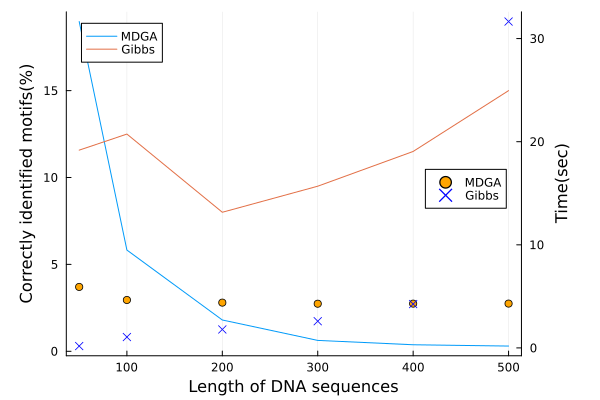

"/Users/sangmi_jeong/Documents/julia/Test1_1.pdf"

In [138]:
# Gibbs results
gibbs = read_gibbs(test)

x = [50; 100:100:500;]

# Compare the occurance(%) and running time
gr()
plot1_1 = plot(x, occurance, label="MDGA(%)", legend=:topleft,
    ylabel="Correctly identified motifs(%)",
    left_margin = 5Plots.mm, right_margin = 8Plots.mm)
plot!(x, gibbs[2], label="Gibbs(%)")
xlabel!("Length of DNA sequences")
axis2 = twinx()
scatter!(axis2, x, running_time, color=:orange, label="MDGA(sec)")
scatter!(axis2, x, gibbs[1], color=:blue, markershape=:x, label="Gibbs(sec)",
    ylabel="Time(sec)", legend=:right)
display(plot1_1)
savefig("Test1_1.pdf")

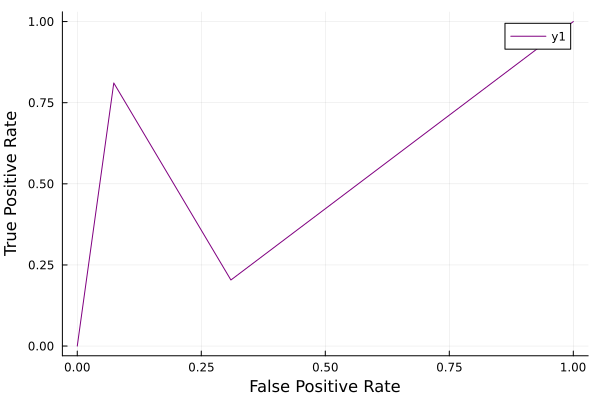

In [146]:
df = DataFrame( TPR = [0; sensitivity[1]; 1], FPR = [0; ones(rep) - specificity[1]; 1])
sort!(df, :FPR)

gr()
plot1_2 = plot(df[!,:FPR], df[!,:TPR], color=:purple,
        ylabel="True Positive Rate", xlabel="False Positive Rate")
display(plot1_2)
savefig("Test1_2.pdf")

### TEST 2

t = 20 --------------------# num of DNA seqs  <br>
**k = 10,12,14,16,18,20 ---------------------# Motif length**     <br>
m = consensus_motif(k) -----# consensus motif(implanted)  <br>
l = 100 --------------------# DNA length       <br>
mut = 1 --------------------# num of mutations <br> 
filename = "test2" ---------# file in fasta format <br>

In [153]:
test = "test2"
width=[10:2:20;]
rep=200
conditions = 6

running_time2 = []
occurance2 = []
sensitivity2 = fill([], conditions)
specificity2 = fill([], conditions)

for i in 1:conditions
    println("simulation", i)
    files = read_files(test*"-"*string(i))
    seqs = files[1]
    actual_motifs = files[2]
    motif_pos = files[3]
    
    w = width[i]
    result = simul(seqs, actual_motifs, motif_pos, w, rep)
    push!(running_time2, sum(result[4])/rep); println(running_time2)
    push!(occurance2, sum(result[5])/rep); println(occurance2)
    sensitivity2[i] = result[6]; println(sensitivity2)
    specificity2[i] = result[7]; println(specificity2)
    
end

simulation1
repeat 1
repeat 2
repeat 3
repeat 4
repeat 5
repeat 6
repeat 7
repeat 8
repeat 9
repeat 10
repeat 11
repeat 12
repeat 13
repeat 14
repeat 15
repeat 16
repeat 17
repeat 18
repeat 19
repeat 20
repeat 21
repeat 22
repeat 23
repeat 24
repeat 25
repeat 26
repeat 27
repeat 28
repeat 29
repeat 30
repeat 31
repeat 32
repeat 33
repeat 34
repeat 35
repeat 36
repeat 37
repeat 38
repeat 39
repeat 40
repeat 41
repeat 42
repeat 43
repeat 44
repeat 45
repeat 46
repeat 47
repeat 48
repeat 49
repeat 50
repeat 51
repeat 52
repeat 53
repeat 54
repeat 55
repeat 56
repeat 57
repeat 58
repeat 59
repeat 60
repeat 61
repeat 62
repeat 63
repeat 64
repeat 65
repeat 66
repeat 67
repeat 68
repeat 69
repeat 70
repeat 71
repeat 72
repeat 73
repeat 74
repeat 75
repeat 76
repeat 77
repeat 78
repeat 79
repeat 80
repeat 81
repeat 82
repeat 83
repeat 84
repeat 85
repeat 86
repeat 87
repeat 88
repeat 89
repeat 90
repeat 91
repeat 92
repeat 93
repeat 94
repeat 95
repeat 96
repeat 97
repeat 98
repeat 99
repeat 

repeat 95
repeat 96
repeat 97
repeat 98
repeat 99
repeat 100
repeat 101
repeat 102
repeat 103
repeat 104
repeat 105
repeat 106
repeat 107
repeat 108
repeat 109
repeat 110
repeat 111
repeat 112
repeat 113
repeat 114
repeat 115
repeat 116
repeat 117
repeat 118
repeat 119
repeat 120
repeat 121
repeat 122
repeat 123
repeat 124
repeat 125
repeat 126
repeat 127
repeat 128
repeat 129
repeat 130
repeat 131
repeat 132
repeat 133
repeat 134
repeat 135
repeat 136
repeat 137
repeat 138
repeat 139
repeat 140
repeat 141
repeat 142
repeat 143
repeat 144
repeat 145
repeat 146
repeat 147
repeat 148
repeat 149
repeat 150
repeat 151
repeat 152
repeat 153
repeat 154
repeat 155
repeat 156
repeat 157
repeat 158
repeat 159
repeat 160
repeat 161
repeat 162
repeat 163
repeat 164
repeat 165
repeat 166
repeat 167
repeat 168
repeat 169
repeat 170
repeat 171
repeat 172
repeat 173
repeat 174
repeat 175
repeat 176
repeat 177
repeat 178
repeat 179
repeat 180
repeat 181
repeat 182
repeat 183
repeat 184
repeat 185
repe

Vector{Any}[[0.9061111111111111, 0.8961111111111111, 0.9155555555555556, 0.8988888888888888, 0.8994444444444445, 0.8922222222222222, 0.9333333333333333, 0.8988888888888888, 0.9072222222222223, 0.9311111111111111, 0.9122222222222223, 0.9044444444444445, 0.8933333333333333, 0.8961111111111111, 0.9033333333333333, 0.9005555555555556, 0.9127777777777778, 0.92, 0.9194444444444444, 0.8922222222222222, 0.915, 0.9, 0.9088888888888889, 0.8955555555555555, 0.8933333333333333, 0.9061111111111111, 0.9161111111111111, 0.9077777777777778, 0.9022222222222223, 0.8938888888888888, 0.9038888888888889, 0.9077777777777778, 0.8894444444444445, 0.91, 0.8955555555555555, 0.8944444444444445, 0.9, 0.8988888888888888, 0.9055555555555556, 0.8944444444444445, 0.91, 0.9033333333333333, 0.8972222222222223, 0.8938888888888888, 0.9172222222222223, 0.9116666666666666, 0.9066666666666666, 0.91, 0.9061111111111111, 0.8888888888888888, 0.9027777777777778, 0.8944444444444445, 0.8933333333333333, 0.9111111111111111, 0.8977

repeat 73
repeat 74
repeat 75
repeat 76
repeat 77
repeat 78
repeat 79
repeat 80
repeat 81
repeat 82
repeat 83
repeat 84
repeat 85
repeat 86
repeat 87
repeat 88
repeat 89
repeat 90
repeat 91
repeat 92
repeat 93
repeat 94
repeat 95
repeat 96
repeat 97
repeat 98
repeat 99
repeat 100
repeat 101
repeat 102
repeat 103
repeat 104
repeat 105
repeat 106
repeat 107
repeat 108
repeat 109
repeat 110
repeat 111
repeat 112
repeat 113
repeat 114
repeat 115
repeat 116
repeat 117
repeat 118
repeat 119
repeat 120
repeat 121
repeat 122
repeat 123
repeat 124
repeat 125
repeat 126
repeat 127
repeat 128
repeat 129
repeat 130
repeat 131
repeat 132
repeat 133
repeat 134
repeat 135
repeat 136
repeat 137
repeat 138
repeat 139
repeat 140
repeat 141
repeat 142
repeat 143
repeat 144
repeat 145
repeat 146
repeat 147
repeat 148
repeat 149
repeat 150
repeat 151
repeat 152
repeat 153
repeat 154
repeat 155
repeat 156
repeat 157
repeat 158
repeat 159
repeat 160
repeat 161
repeat 162
repeat 163
repeat 164
repeat 165
repe

Vector{Any}[[0.9061111111111111, 0.8961111111111111, 0.9155555555555556, 0.8988888888888888, 0.8994444444444445, 0.8922222222222222, 0.9333333333333333, 0.8988888888888888, 0.9072222222222223, 0.9311111111111111, 0.9122222222222223, 0.9044444444444445, 0.8933333333333333, 0.8961111111111111, 0.9033333333333333, 0.9005555555555556, 0.9127777777777778, 0.92, 0.9194444444444444, 0.8922222222222222, 0.915, 0.9, 0.9088888888888889, 0.8955555555555555, 0.8933333333333333, 0.9061111111111111, 0.9161111111111111, 0.9077777777777778, 0.9022222222222223, 0.8938888888888888, 0.9038888888888889, 0.9077777777777778, 0.8894444444444445, 0.91, 0.8955555555555555, 0.8944444444444445, 0.9, 0.8988888888888888, 0.9055555555555556, 0.8944444444444445, 0.91, 0.9033333333333333, 0.8972222222222223, 0.8938888888888888, 0.9172222222222223, 0.9116666666666666, 0.9066666666666666, 0.91, 0.9061111111111111, 0.8888888888888888, 0.9027777777777778, 0.8944444444444445, 0.8933333333333333, 0.9111111111111111, 0.8977

...

 0.8627906976744186, 0.8825581395348837, 0.8732558139534884, 0.888953488372093, 0.8773255813953489, 0.861046511627907, 0.8976744186046511, 0.8947674418604651, 0.8662790697674418, 0.8860465116279069, 0.8651162790697674, 0.8901162790697674, 0.8662790697674418, 0.8761627906976744, 0.8761627906976744, 0.8872093023255814, 0.8575581395348837, 0.8808139534883721, 0.8912790697674419, 0.8965116279069767, 0.8959302325581395, 0.875, 0.8622093023255814, 0.8715116279069768, 0.9, 0.8965116279069767, 0.9162790697674419, 0.8790697674418605, 0.861046511627907, 0.8877906976744186, 0.8790697674418605, 0.8843023255813953, 0.85, 0.8639534883720931, 0.8837209302325582, 0.8558139534883721, 0.872093023255814, 0.872093023255814, 0.8593023255813953, 0.8877906976744186, 0.9186046511627907, 0.8941860465116279, 0.8732558139534884, 0.9029069767441861, 0.8883720930232558, 0.8784883720930232, 0.8697674418604651, 0.852906976744186, 0.8616279069767442, 0.8866279069767442, 0.8505813953488373, 0.8872093023255814, 0.87151

 0.85, 0.822560975609756, 0.8634146341463415, 0.8365853658536585, 0.8670731707317073, 0.8347560975609756, 0.8317073170731707, 0.8353658536585366], []]
simulation6
repeat 1
repeat 2
repeat 3
repeat 4
repeat 5
repeat 6
repeat 7
repeat 8
repeat 9
repeat 10
repeat 11
repeat 12
repeat 13
repeat 14
repeat 15
repeat 16
repeat 17
repeat 18
repeat 19
repeat 20
repeat 21
repeat 22
repeat 23
repeat 24
repeat 25
repeat 26
repeat 27
repeat 28
repeat 29
repeat 30
repeat 31
repeat 32
repeat 33
repeat 34
repeat 35
repeat 36
repeat 37
repeat 38
repeat 39
repeat 40
repeat 41
repeat 42
repeat 43
repeat 44
repeat 45
repeat 46
repeat 47
repeat 48
repeat 49
repeat 50
repeat 51
repeat 52
repeat 53
repeat 54
repeat 55
repeat 56
repeat 57
repeat 58
repeat 59
repeat 60
repeat 61
repeat 62
repeat 63
repeat 64
repeat 65
repeat 66
repeat 67
repeat 68
repeat 69
repeat 70
repeat 71
repeat 72
repeat 73
repeat 74
repeat 75
repeat 76
repeat 77
repeat 78
repeat 79
repeat 80
repeat 81
repeat 82
repeat 83
repeat 84
repeat

Vector{Any}[[0.155, 0.065, 0.24, 0.09, 0.095, 0.03, 0.4, 0.09, 0.165, 0.38, 0.21, 0.14, 0.04, 0.065, 0.13, 0.105, 0.215, 0.28, 0.275, 0.03, 0.235, 0.1, 0.18, 0.06, 0.04, 0.155, 0.245, 0.17, 0.12, 0.045, 0.135, 0.17, 0.005, 0.19, 0.06, 0.05, 0.1, 0.09, 0.15, 0.05, 0.19, 0.13, 0.075, 0.045, 0.255, 0.205, 0.16, 0.19, 0.155, 0.0, 0.125, 0.05, 0.04, 0.2, 0.08, 0.185, 0.205, 0.125, 0.205, 0.195, 0.185, 0.15, 0.03, 0.14, 0.27, 0.095, 0.085, 0.14, 0.215, 0.29, 0.11, 0.07, 0.385, 0.095, 0.04, 0.135, 0.16, 0.08, 0.115, 0.08, 0.215, 0.295, 0.21, 0.265, 0.15, 0.22, 0.06, 0.24, 0.07, 0.06, 0.13, 0.185, 0.115, 0.26, 0.195, 0.305, 0.105, 0.075, 0.045, 0.0, 0.11, 0.175, 0.315, 0.25, 0.295, 0.25, 0.13, 0.265, 0.075, 0.335, 0.225, 0.225, 0.095, 0.19, 0.02, 0.35, 0.13, 0.31, 0.145, 0.05, 0.085, 0.285, 0.095, 0.22, 0.165, 0.08, 0.06, 0.1, 0.235, 0.06, 0.13, 0.205, 0.19, 0.11, 0.115, 0.185, 0.295, 0.14, 0.035, 0.045, 0.18, 0.14, 0.09, 0.255, 0.355, 0.075, 0.025, 0.105, 0.13, 0.065, 0.385, 0.115, 0.22, 0.03

Vector{Any}[[0.9061111111111111, 0.8961111111111111, 0.9155555555555556, 0.8988888888888888, 0.8994444444444445, 0.8922222222222222, 0.9333333333333333, 0.8988888888888888, 0.9072222222222223, 0.9311111111111111, 0.9122222222222223, 0.9044444444444445, 0.8933333333333333, 0.8961111111111111, 0.9033333333333333, 0.9005555555555556, 0.9127777777777778, 0.92, 0.9194444444444444, 0.8922222222222222, 0.915, 0.9, 0.9088888888888889, 0.8955555555555555, 0.8933333333333333, 0.9061111111111111, 0.9161111111111111, 0.9077777777777778, 0.9022222222222223, 0.8938888888888888, 0.9038888888888889, 0.9077777777777778, 0.8894444444444445, 0.91, 0.8955555555555555, 0.8944444444444445, 0.9, 0.8988888888888888, 0.9055555555555556, 0.8944444444444445, 0.91, 0.9033333333333333, 0.8972222222222223, 0.8938888888888888, 0.9172222222222223, 0.9116666666666666, 0.9066666666666666, 0.91, 0.9061111111111111, 0.8888888888888888, 0.9027777777777778, 0.8944444444444445, 0.8933333333333333, 0.9111111111111111, 0.8977

 0.8689024390243902, 0.8158536585365853, 0.8573170731707317, 0.8786585365853659, 0.8914634146341464, 0.8829268292682927, 0.848170731707317, 0.8384146341463414, 0.8378048780487805, 0.8530487804878049, 0.8603658536585366, 0.8542682926829268, 0.8304878048780487, 0.8390243902439024, 0.8097560975609757, 0.8792682926829268, 0.8091463414634147, 0.8323170731707317, 0.8371951219512195, 0.8603658536585366, 0.8676829268292683, 0.8414634146341463, 0.8579268292682927, 0.8439024390243902, 0.8603658536585366, 0.8146341463414634, 0.8298780487804878, 0.8859756097560976, 0.8457317073170731, 0.85, 0.8219512195121951, 0.848780487804878, 0.8268292682926829, 0.8707317073170732, 0.8475609756097561, 0.9121951219512195, 0.8432926829268292, 0.848170731707317, 0.824390243902439, 0.8548780487804878, 0.8817073170731707, 0.8079268292682927, 0.8646341463414634, 0.8701219512195122, 0.8804878048780488, 0.8609756097560975, 0.8628048780487805, 0.8725609756097561, 0.8591463414634146, 0.8780487804878049, 0.837804878048780

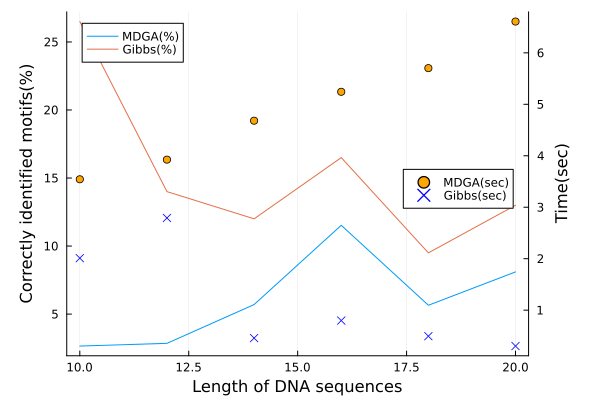

"/Users/sangmi_jeong/Documents/julia/Test2_1.pdf"

In [154]:
# Gibbs results
gibbs2 = read_gibbs(test)

x = [10:2:20;]

# Compare the occurance(%) and running time
gr()
plot2_1 = plot(x, occurance2, label="MDGA(%)", legend=:topleft,
    ylabel="Correctly identified motifs(%)",
    left_margin = 5Plots.mm, right_margin = 8Plots.mm)
plot!(x, gibbs2[2], label="Gibbs(%)")
xlabel!("Length of DNA sequences")
axis2 = twinx()
scatter!(axis2, x, running_time2, color=:orange, label="MDGA(sec)")
scatter!(axis2, x, gibbs2[1], color=:blue, markershape=:x, label="Gibbs(sec)",
    ylabel="Time(sec)", legend=:right)
display(plot2_1)
savefig("Test2_1.pdf")

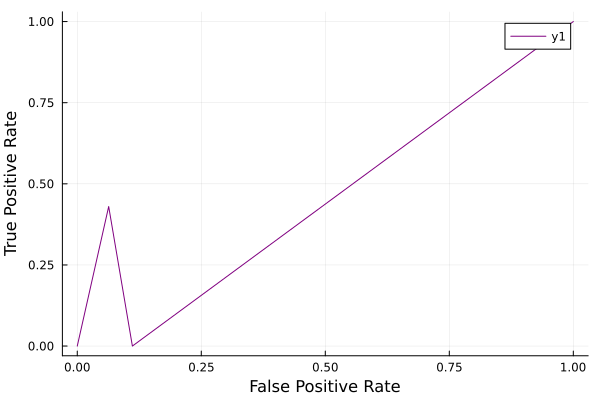

"/Users/sangmi_jeong/Documents/julia/Test2_2.pdf"

In [155]:
df2 = DataFrame( TPR = [0; sensitivity2[1]; 1], FPR = [0; ones(rep) - specificity2[1]; 1])
sort!(df2, :FPR)
        
gr()
plot2_2 = plot(df2[!,:FPR], df2[!,:TPR], color=:purple,
        ylabel="True Positive Rate", xlabel="False Positive Rate")
display(plot2_2)
savefig("Test2_2.pdf")

### TEST 3

**t = 10, 30, 50, 70 --------------------# num of DNA seqs **  <br>
k = 14 ---------------------# Motif length     <br>
m = consensus_motif(k) -----# consensus motif(implanted)  <br>
l = 100 --------------------# DNA length       <br>
mut = 1 --------------------# num of mutations <br> 
filename = "test2" ---------# file in fasta format <br>

In [162]:
test = "test3"
width=14
rep=100
conditions = 4

running_time3 = []
occurance3 = []
sensitivity3 = fill([], conditions)
specificity3 = fill([], conditions)

for i in 1:conditions
    println("simulation", i)
    files = read_files(test*"-"*string(i))
    seqs = files[1]
    actual_motifs = files[2]
    motif_pos = files[3]
    
    result = simul(seqs, actual_motifs, motif_pos, width, rep)
    push!(running_time3, sum(result[4])/rep); println(running_time3)
    push!(occurance3, sum(result[5])/rep); println(occurance3)
    sensitivity3[i] = result[6]; println(sensitivity3)
    specificity3[i] = result[7]; println(specificity3)
    
end

simulation1
repeat 1
repeat 2
repeat 3
repeat 4
repeat 5
repeat 6
repeat 7
repeat 8
repeat 9
repeat 10
repeat 11
repeat 12
repeat 13
repeat 14
repeat 15
repeat 16
repeat 17
repeat 18
repeat 19
repeat 20
repeat 21
repeat 22
repeat 23
repeat 24
repeat 25
repeat 26
repeat 27
repeat 28
repeat 29
repeat 30
repeat 31
repeat 32
repeat 33
repeat 34
repeat 35
repeat 36
repeat 37
repeat 38
repeat 39
repeat 40
repeat 41
repeat 42
repeat 43
repeat 44
repeat 45
repeat 46
repeat 47
repeat 48
repeat 49
repeat 50
repeat 51
repeat 52
repeat 53
repeat 54
repeat 55
repeat 56
repeat 57
repeat 58
repeat 59
repeat 60
repeat 61
repeat 62
repeat 63
repeat 64
repeat 65
repeat 66
repeat 67
repeat 68
repeat 69
repeat 70
repeat 71
repeat 72
repeat 73
repeat 74
repeat 75
repeat 76
repeat 77
repeat 78
repeat 79
repeat 80
repeat 81
repeat 82
repeat 83
repeat 84
repeat 85
repeat 86
repeat 87
repeat 88
repeat 89
repeat 90
repeat 91
repeat 92
repeat 93
repeat 94
repeat 95
repeat 96
repeat 97
repeat 98
repeat 99
repeat 

repeat 2
repeat 3
repeat 4
repeat 5
repeat 6
repeat 7
repeat 8
repeat 9
repeat 10
repeat 11
repeat 12
repeat 13
repeat 14
repeat 15
repeat 16
repeat 17
repeat 18
repeat 19
repeat 20
repeat 21
repeat 22
repeat 23
repeat 24
repeat 25
repeat 26
repeat 27
repeat 28
repeat 29
repeat 30
repeat 31
repeat 32
repeat 33
repeat 34
repeat 35
repeat 36
repeat 37
repeat 38
repeat 39
repeat 40
repeat 41
repeat 42
repeat 43
repeat 44
repeat 45
repeat 46
repeat 47
repeat 48
repeat 49
repeat 50
repeat 51
repeat 52
repeat 53
repeat 54
repeat 55
repeat 56
repeat 57
repeat 58
repeat 59
repeat 60
repeat 61
repeat 62
repeat 63
repeat 64
repeat 65
repeat 66
repeat 67
repeat 68
repeat 69
repeat 70
repeat 71
repeat 72
repeat 73
repeat 74
repeat 75
repeat 76
repeat 77
repeat 78
repeat 79
repeat 80
repeat 81
repeat 82
repeat 83
repeat 84
repeat 85
repeat 86
repeat 87
repeat 88
repeat 89
repeat 90
repeat 91
repeat 92
repeat 93
repeat 94
repeat 95
repeat 96
repeat 97
repeat 98
repeat 99
repeat 100
Any[6.12897259803

Vector{Any}[[0.8372093023255814, 0.9174418604651163, 0.8558139534883721, 0.8790697674418605, 0.9093023255813953, 0.8511627906976744, 0.9104651162790698, 0.8453488372093023, 0.8790697674418605, 0.8767441860465116, 0.8953488372093024, 0.891860465116279, 0.9348837209302325, 0.891860465116279, 0.8709302325581395, 0.877906976744186, 0.8755813953488372, 0.9279069767441861, 0.8965116279069767, 0.8558139534883721, 0.858139534883721, 0.9279069767441861, 0.8476744186046512, 0.8825581395348837, 0.9267441860465117, 0.8418604651162791, 0.8837209302325582, 0.8476744186046512, 0.8593023255813953, 0.8802325581395349, 0.8837209302325582, 0.8651162790697674, 0.9186046511627907, 0.8639534883720931, 0.9023255813953488, 0.8569767441860465, 0.8930232558139535, 0.8930232558139535, 0.8488372093023255, 0.8837209302325582, 0.9046511627906977, 0.9023255813953488, 0.8674418604651163, 0.8372093023255814, 0.8883720930232558, 0.9, 0.8523255813953489, 0.877906976744186, 0.8988372093023256, 0.9046511627906977, 0.87441

Vector{Any}[[0.8372093023255814, 0.9174418604651163, 0.8558139534883721, 0.8790697674418605, 0.9093023255813953, 0.8511627906976744, 0.9104651162790698, 0.8453488372093023, 0.8790697674418605, 0.8767441860465116, 0.8953488372093024, 0.891860465116279, 0.9348837209302325, 0.891860465116279, 0.8709302325581395, 0.877906976744186, 0.8755813953488372, 0.9279069767441861, 0.8965116279069767, 0.8558139534883721, 0.858139534883721, 0.9279069767441861, 0.8476744186046512, 0.8825581395348837, 0.9267441860465117, 0.8418604651162791, 0.8837209302325582, 0.8476744186046512, 0.8593023255813953, 0.8802325581395349, 0.8837209302325582, 0.8651162790697674, 0.9186046511627907, 0.8639534883720931, 0.9023255813953488, 0.8569767441860465, 0.8930232558139535, 0.8930232558139535, 0.8488372093023255, 0.8837209302325582, 0.9046511627906977, 0.9023255813953488, 0.8674418604651163, 0.8372093023255814, 0.8883720930232558, 0.9, 0.8523255813953489, 0.877906976744186, 0.8988372093023256, 0.9046511627906977, 0.87441

repeat 23
repeat 24
repeat 25
repeat 26
repeat 27
repeat 28
repeat 29
repeat 30
repeat 31
repeat 32
repeat 33
repeat 34
repeat 35
repeat 36
repeat 37
repeat 38
repeat 39
repeat 40
repeat 41
repeat 42
repeat 43
repeat 44
repeat 45
repeat 46
repeat 47
repeat 48
repeat 49
repeat 50
repeat 51
repeat 52
repeat 53
repeat 54
repeat 55
repeat 56
repeat 57
repeat 58
repeat 59
repeat 60
repeat 61
repeat 62
repeat 63
repeat 64
repeat 65
repeat 66
repeat 67
repeat 68
repeat 69
repeat 70
repeat 71
repeat 72
repeat 73
repeat 74
repeat 75
repeat 76
repeat 77
repeat 78
repeat 79
repeat 80
repeat 81
repeat 82
repeat 83
repeat 84
repeat 85
repeat 86
repeat 87
repeat 88
repeat 89
repeat 90
repeat 91
repeat 92
repeat 93
repeat 94
repeat 95
repeat 96
repeat 97
repeat 98
repeat 99
repeat 100
Any[6.128972598038829, 3.4653644248076834, 2.3477771950388946, 1.8237005230673957, 2.3952896399833774]
Any[9.6, 2.666666666666667, 0.92, 1.3714285714285714, 1.06]
Vector{Any}[[0.0, 0.4928571428571429, 0.1142857142857142

...

 0.856312292358804, 0.8598006644518272, 0.8606312292358804, 0.8729235880398671, 0.8641196013289036, 0.8642857142857143, 0.8777408637873754, 0.8578073089700997, 0.8679401993355482, 0.8604651162790697, 0.8602990033222592, 0.8599667774086379, 0.868936877076412, 0.8554817275747508, 0.8646179401993356, 0.8568106312292358, 0.8827242524916944, 0.8598006644518272, 0.8699335548172757, 0.868936877076412, 0.8616279069767442, 0.8646179401993356, 0.8621262458471761, 0.8583056478405315, 0.8583056478405315, 0.873421926910299, 0.8649501661129568, 0.8803986710963455, 0.8606312292358804, 0.8664451827242525, 0.8611295681063122, 0.8664451827242525, 0.858970099667774, 0.8574750830564785, 0.8612956810631229, 0.8666112956810631, 0.8652823920265781, 0.8739202657807309, 0.8669435215946844, 0.8835548172757475, 0.8646179401993356, 0.8667774086378738, 0.8705980066445183, 0.8586378737541528, 0.8832225913621262, 0.8647840531561461, 0.8664451827242525, 0.8659468438538206, 0.8649501661129568, 0.8596345514950167, 0.87

Vector{Any}[[0.0, 0.4928571428571429, 0.11428571428571428, 0.2571428571428571, 0.44285714285714284, 0.08571428571428572, 0.45, 0.05, 0.2571428571428571, 0.24285714285714285, 0.35714285714285715, 0.3357142857142857, 0.6, 0.3357142857142857, 0.20714285714285716, 0.25, 0.2357142857142857, 0.5571428571428572, 0.36428571428571427, 0.11428571428571428, 0.12857142857142856, 0.5571428571428572, 0.06428571428571428, 0.2785714285714286, 0.55, 0.02857142857142857, 0.2857142857142857, 0.06428571428571428, 0.1357142857142857, 0.2642857142857143, 0.2857142857142857, 0.17142857142857143, 0.5, 0.16428571428571428, 0.4, 0.12142857142857143, 0.34285714285714286, 0.34285714285714286, 0.07142857142857142, 0.2857142857142857, 0.4142857142857143, 0.4, 0.18571428571428572, 0.0, 0.3142857142857143, 0.38571428571428573, 0.09285714285714286, 0.25, 0.37857142857142856, 0.4142857142857143, 0.22857142857142856, 0.12142857142857143, 0.42142857142857143, 0.07142857142857142, 0.34285714285714286, 0.5928571428571429, 

Vector{Any}[[0.8372093023255814, 0.9174418604651163, 0.8558139534883721, 0.8790697674418605, 0.9093023255813953, 0.8511627906976744, 0.9104651162790698, 0.8453488372093023, 0.8790697674418605, 0.8767441860465116, 0.8953488372093024, 0.891860465116279, 0.9348837209302325, 0.891860465116279, 0.8709302325581395, 0.877906976744186, 0.8755813953488372, 0.9279069767441861, 0.8965116279069767, 0.8558139534883721, 0.858139534883721, 0.9279069767441861, 0.8476744186046512, 0.8825581395348837, 0.9267441860465117, 0.8418604651162791, 0.8837209302325582, 0.8476744186046512, 0.8593023255813953, 0.8802325581395349, 0.8837209302325582, 0.8651162790697674, 0.9186046511627907, 0.8639534883720931, 0.9023255813953488, 0.8569767441860465, 0.8930232558139535, 0.8930232558139535, 0.8488372093023255, 0.8837209302325582, 0.9046511627906977, 0.9023255813953488, 0.8674418604651163, 0.8372093023255814, 0.8883720930232558, 0.9, 0.8523255813953489, 0.877906976744186, 0.8988372093023256, 0.9046511627906977, 0.87441

, 0.8641860465116279, 0.8586046511627907, 0.8611627906976744, 0.8693023255813953, 0.8611627906976744, 0.868139534883721, 0.8675581395348837, 0.8552325581395349, 0.8659302325581395, 0.8652325581395349, 0.8748837209302326, 0.8665116279069768, 0.8527906976744186, 0.8598837209302326, 0.8582558139534884, 0.8570930232558139, 0.8595348837209302, 0.8525581395348837, 0.8626744186046512, 0.861046511627907, 0.8670930232558139, 0.8589534883720931, 0.8616279069767442, 0.8625581395348837, 0.8634883720930232, 0.8663953488372093, 0.861046511627907, 0.8627906976744186, 0.8706976744186047, 0.8695348837209302, 0.8608139534883721, 0.8591860465116279, 0.8686046511627907, 0.8601162790697674, 0.8665116279069768, 0.8708139534883721, 0.8824418604651163, 0.8618604651162791, 0.8698837209302326, 0.875, 0.8602325581395349, 0.8601162790697674, 0.8576744186046512, 0.8647674418604652, 0.8654651162790697, 0.876860465116279, 0.873139534883721, 0.8575581395348837, 0.8601162790697674, 0.8606976744186047, 0.85837209302325

LoadError: SystemError: opening file "/Users/sangmi_jeong/Documents/julia/test3-11.fasta": No such file or directory

In [161]:
# Gibbs results
test="test3"
gibbs3 = read_gibbs(test)

x = [10:10:100;]

# Compare the occurance(%) and running time
gr()
plot3_1 = plot(x, occurance3, label="MDGA(%)", legend=:topleft,
    ylabel="Correctly identified motifs(%)",
    left_margin = 5Plots.mm, right_margin = 8Plots.mm)
plot!(x, gibbs3[2], label="Gibbs(%)")
xlabel!("Length of DNA sequences")
axis2 = twinx()
scatter!(axis2, x, running_time3, color=:orange, label="MDGA(sec)")
scatter!(axis2, x, gibbs3[1], color=:blue, markershape=:x, label="Gibbs(sec)",
    ylabel="Time(sec)", legend=:right)
display(plot3_1)
savefig("Test3_1.pdf")

LoadError: SystemError: opening file "/Users/sangmi_jeong/Documents/julia/test3_time.txt": No such file or directory

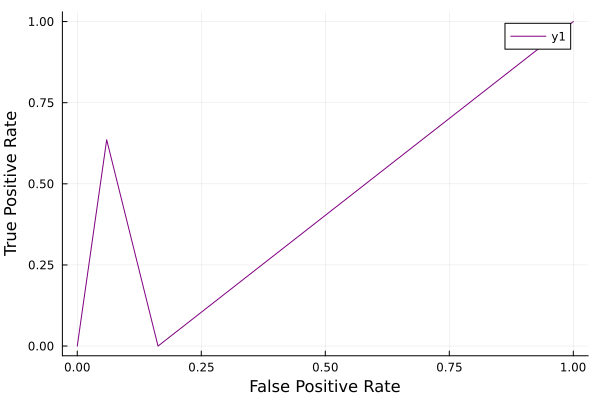

"/Users/sangmi_jeong/Documents/julia/Test3_2.pdf"

In [158]:
df3 = DataFrame( TPR = [0; sensitivity3[1]; 1], FPR = [0; ones(rep) - specificity3[1]; 1])
sort!(df3, :FPR)
        
gr()
plot3_2 = plot(df3[!,:FPR], df3[!,:TPR], color=:purple,
        ylabel="True Positive Rate", xlabel="False Positive Rate")
display(plot3_2)
savefig("Test3_2.pdf")

### TEST 4

t = 20 --------------------# num of DNA seqs  <br>
k = 14 ---------------------# Motif length     <br>
m = consensus_motif(k) -----# consensus motif(implanted)  <br>
l = 100 --------------------# DNA length       <br>
**mut = 1,2,3,4,5 --------------------# num of mutations <br> ** 
filename = "test2" ---------# file in fasta format <br>

In [159]:
test = "test4"
width=14
rep=200
conditions = 5

running_time4 = []
occurance4 = []
sensitivity4 = fill([], conditions)
specificity4 = fill([], conditions)

for i in 1:conditions
    println("simulation", i)
    files = read_files(test*"-"*string(i))
    seqs = files[1]
    actual_motifs = files[2]
    motif_pos = files[3]
    
    result = simul(seqs, actual_motifs, motif_pos, width, rep)
    push!(running_time4, sum(result[4])/rep); println(running_time4)
    push!(occurance4, sum(result[5])/rep); println(occurance4)
    sensitivity4[i] = result[6]; println(sensitivity4)
    specificity4[i] = result[7]; println(specificity4)
    
end

simulation1
repeat 1
repeat 2
repeat 3
repeat 4
repeat 5
repeat 6
repeat 7
repeat 8
repeat 9
repeat 10
repeat 11
repeat 12
repeat 13
repeat 14
repeat 15
repeat 16
repeat 17
repeat 18
repeat 19
repeat 20
repeat 21
repeat 22
repeat 23
repeat 24
repeat 25
repeat 26
repeat 27
repeat 28
repeat 29
repeat 30
repeat 31
repeat 32
repeat 33
repeat 34
repeat 35
repeat 36
repeat 37
repeat 38
repeat 39
repeat 40
repeat 41
repeat 42
repeat 43
repeat 44
repeat 45
repeat 46
repeat 47
repeat 48
repeat 49
repeat 50
repeat 51
repeat 52
repeat 53
repeat 54
repeat 55
repeat 56
repeat 57
repeat 58
repeat 59
repeat 60
repeat 61
repeat 62
repeat 63
repeat 64
repeat 65
repeat 66
repeat 67
repeat 68
repeat 69
repeat 70
repeat 71
repeat 72
repeat 73
repeat 74
repeat 75
repeat 76
repeat 77
repeat 78
repeat 79
repeat 80
repeat 81
repeat 82
repeat 83
repeat 84
repeat 85
repeat 86
repeat 87
repeat 88
repeat 89
repeat 90
repeat 91
repeat 92
repeat 93
repeat 94
repeat 95
repeat 96
repeat 97
repeat 98
repeat 99
repeat 

repeat 2
repeat 3
repeat 4
repeat 5
repeat 6
repeat 7
repeat 8
repeat 9
repeat 10
repeat 11
repeat 12
repeat 13
repeat 14
repeat 15
repeat 16
repeat 17
repeat 18
repeat 19
repeat 20
repeat 21
repeat 22
repeat 23
repeat 24
repeat 25
repeat 26
repeat 27
repeat 28
repeat 29
repeat 30
repeat 31
repeat 32
repeat 33
repeat 34
repeat 35
repeat 36
repeat 37
repeat 38
repeat 39
repeat 40
repeat 41
repeat 42
repeat 43
repeat 44
repeat 45
repeat 46
repeat 47
repeat 48
repeat 49
repeat 50
repeat 51
repeat 52
repeat 53
repeat 54
repeat 55
repeat 56
repeat 57
repeat 58
repeat 59
repeat 60
repeat 61
repeat 62
repeat 63
repeat 64
repeat 65
repeat 66
repeat 67
repeat 68
repeat 69
repeat 70
repeat 71
repeat 72
repeat 73
repeat 74
repeat 75
repeat 76
repeat 77
repeat 78
repeat 79
repeat 80
repeat 81
repeat 82
repeat 83
repeat 84
repeat 85
repeat 86
repeat 87
repeat 88
repeat 89
repeat 90
repeat 91
repeat 92
repeat 93
repeat 94
repeat 95
repeat 96
repeat 97
repeat 98
repeat 99
repeat 100
repeat 101
repeat

Vector{Any}[[0.8593023255813953, 0.911046511627907, 0.8563953488372092, 0.8674418604651163, 0.891860465116279, 0.8994186046511627, 0.8668604651162791, 0.8540697674418605, 0.8808139534883721, 0.8465116279069768, 0.8790697674418605, 0.875, 0.8476744186046512, 0.8651162790697674, 0.8622093023255814, 0.8686046511627907, 0.8593023255813953, 0.8831395348837209, 0.8424418604651163, 0.8744186046511628, 0.875, 0.8872093023255814, 0.8965116279069767, 0.8674418604651163, 0.8563953488372092, 0.8813953488372093, 0.8622093023255814, 0.8686046511627907, 0.8412790697674418, 0.8732558139534884, 0.852906976744186, 0.8872093023255814, 0.8505813953488373, 0.8825581395348837, 0.9052325581395348, 0.8546511627906976, 0.8883720930232558, 0.8604651162790697, 0.8825581395348837, 0.8563953488372092, 0.8482558139534884, 0.9093023255813953, 0.8523255813953489, 0.8668604651162791, 0.8936046511627908, 0.8767441860465116, 0.8651162790697674, 0.877906976744186, 0.8598837209302326, 0.9, 0.8523255813953489, 0.8912790697

repeat 35
repeat 36
repeat 37
repeat 38
repeat 39
repeat 40
repeat 41
repeat 42
repeat 43
repeat 44
repeat 45
repeat 46
repeat 47
repeat 48
repeat 49
repeat 50
repeat 51
repeat 52
repeat 53
repeat 54
repeat 55
repeat 56
repeat 57
repeat 58
repeat 59
repeat 60
repeat 61
repeat 62
repeat 63
repeat 64
repeat 65
repeat 66
repeat 67
repeat 68
repeat 69
repeat 70
repeat 71
repeat 72
repeat 73
repeat 74
repeat 75
repeat 76
repeat 77
repeat 78
repeat 79
repeat 80
repeat 81
repeat 82
repeat 83
repeat 84
repeat 85
repeat 86
repeat 87
repeat 88
repeat 89
repeat 90
repeat 91
repeat 92
repeat 93
repeat 94
repeat 95
repeat 96
repeat 97
repeat 98
repeat 99
repeat 100
repeat 101
repeat 102
repeat 103
repeat 104
repeat 105
repeat 106
repeat 107
repeat 108
repeat 109
repeat 110
repeat 111
repeat 112
repeat 113
repeat 114
repeat 115
repeat 116
repeat 117
repeat 118
repeat 119
repeat 120
repeat 121
repeat 122
repeat 123
repeat 124
repeat 125
repeat 126
repeat 127
repeat 128
repeat 129
repeat 130
repeat 13

Vector{Any}[[0.1357142857142857, 0.45357142857142857, 0.11785714285714285, 0.18571428571428572, 0.3357142857142857, 0.3821428571428571, 0.18214285714285713, 0.10357142857142858, 0.26785714285714285, 0.05714285714285714, 0.2571428571428571, 0.23214285714285715, 0.06428571428571428, 0.17142857142857143, 0.15357142857142858, 0.19285714285714287, 0.1357142857142857, 0.28214285714285714, 0.03214285714285714, 0.22857142857142856, 0.23214285714285715, 0.30714285714285716, 0.36428571428571427, 0.18571428571428572, 0.11785714285714285, 0.2714285714285714, 0.15357142857142858, 0.19285714285714287, 0.025, 0.22142857142857142, 0.09642857142857143, 0.30714285714285716, 0.08214285714285714, 0.2785714285714286, 0.41785714285714287, 0.10714285714285714, 0.3142857142857143, 0.14285714285714285, 0.2785714285714286, 0.11785714285714285, 0.06785714285714285, 0.44285714285714284, 0.09285714285714286, 0.18214285714285713, 0.3464285714285714, 0.24285714285714285, 0.17142857142857143, 0.25, 0.1392857142857143

...

Vector{Any}[[0.8593023255813953, 0.911046511627907, 0.8563953488372092, 0.8674418604651163, 0.891860465116279, 0.8994186046511627, 0.8668604651162791, 0.8540697674418605, 0.8808139534883721, 0.8465116279069768, 0.8790697674418605, 0.875, 0.8476744186046512, 0.8651162790697674, 0.8622093023255814, 0.8686046511627907, 0.8593023255813953, 0.8831395348837209, 0.8424418604651163, 0.8744186046511628, 0.875, 0.8872093023255814, 0.8965116279069767, 0.8674418604651163, 0.8563953488372092, 0.8813953488372093, 0.8622093023255814, 0.8686046511627907, 0.8412790697674418, 0.8732558139534884, 0.852906976744186, 0.8872093023255814, 0.8505813953488373, 0.8825581395348837, 0.9052325581395348, 0.8546511627906976, 0.8883720930232558, 0.8604651162790697, 0.8825581395348837, 0.8563953488372092, 0.8482558139534884, 0.9093023255813953, 0.8523255813953489, 0.8668604651162791, 0.8936046511627908, 0.8767441860465116, 0.8651162790697674, 0.877906976744186, 0.8598837209302326, 0.9, 0.8523255813953489, 0.8912790697

0.8552325581395349, 0.8511627906976744, 0.8784883720930232, 0.8406976744186047, 0.8540697674418605, 0.8558139534883721, 0.8697674418604651, 0.8412790697674418, 0.8517441860465116, 0.8470930232558139, 0.8790697674418605, 0.8808139534883721, 0.8848837209302326, 0.8709302325581395, 0.8639534883720931, 0.8773255813953489, 0.8534883720930233, 0.8802325581395349, 0.8732558139534884, 0.8656976744186047, 0.8540697674418605, 0.8598837209302326, 0.8726744186046511, 0.8703488372093023, 0.8604651162790697, 0.8622093023255814, 0.8563953488372092, 0.8767441860465116, 0.8418604651162791, 0.8430232558139535, 0.8569767441860465, 0.8505813953488373, 0.9063953488372093, 0.8703488372093023, 0.858139534883721, 0.8633720930232558, 0.8662790697674418, 0.8755813953488372, 0.8383720930232558, 0.8465116279069768, 0.8465116279069768, 0.875, 0.8563953488372092, 0.8662790697674418, 0.8860465116279069, 0.8796511627906977, 0.8790697674418605, 0.8558139534883721, 0.8866279069767442, 0.9093023255813953, 0.868023255813

Vector{Any}[[0.1357142857142857, 0.45357142857142857, 0.11785714285714285, 0.18571428571428572, 0.3357142857142857, 0.3821428571428571, 0.18214285714285713, 0.10357142857142858, 0.26785714285714285, 0.05714285714285714, 0.2571428571428571, 0.23214285714285715, 0.06428571428571428, 0.17142857142857143, 0.15357142857142858, 0.19285714285714287, 0.1357142857142857, 0.28214285714285714, 0.03214285714285714, 0.22857142857142856, 0.23214285714285715, 0.30714285714285716, 0.36428571428571427, 0.18571428571428572, 0.11785714285714285, 0.2714285714285714, 0.15357142857142858, 0.19285714285714287, 0.025, 0.22142857142857142, 0.09642857142857143, 0.30714285714285716, 0.08214285714285714, 0.2785714285714286, 0.41785714285714287, 0.10714285714285714, 0.3142857142857143, 0.14285714285714285, 0.2785714285714286, 0.11785714285714285, 0.06785714285714285, 0.44285714285714284, 0.09285714285714286, 0.18214285714285713, 0.3464285714285714, 0.24285714285714285, 0.17142857142857143, 0.25, 0.1392857142857143

Vector{Any}[[0.8593023255813953, 0.911046511627907, 0.8563953488372092, 0.8674418604651163, 0.891860465116279, 0.8994186046511627, 0.8668604651162791, 0.8540697674418605, 0.8808139534883721, 0.8465116279069768, 0.8790697674418605, 0.875, 0.8476744186046512, 0.8651162790697674, 0.8622093023255814, 0.8686046511627907, 0.8593023255813953, 0.8831395348837209, 0.8424418604651163, 0.8744186046511628, 0.875, 0.8872093023255814, 0.8965116279069767, 0.8674418604651163, 0.8563953488372092, 0.8813953488372093, 0.8622093023255814, 0.8686046511627907, 0.8412790697674418, 0.8732558139534884, 0.852906976744186, 0.8872093023255814, 0.8505813953488373, 0.8825581395348837, 0.9052325581395348, 0.8546511627906976, 0.8883720930232558, 0.8604651162790697, 0.8825581395348837, 0.8563953488372092, 0.8482558139534884, 0.9093023255813953, 0.8523255813953489, 0.8668604651162791, 0.8936046511627908, 0.8767441860465116, 0.8651162790697674, 0.877906976744186, 0.8598837209302326, 0.9, 0.8523255813953489, 0.8912790697

, [0.8744186046511628, 0.8494186046511628, 0.858139534883721, 0.8447674418604652, 0.877906976744186, 0.8441860465116279, 0.8656976744186047, 0.8563953488372092, 0.8802325581395349, 0.877906976744186, 0.8715116279069768, 0.8936046511627908, 0.8843023255813953, 0.8546511627906976, 0.852906976744186, 0.8686046511627907, 0.8819767441860465, 0.8645348837209302, 0.8558139534883721, 0.872093023255814, 0.875, 0.8680232558139535, 0.8569767441860465, 0.8976744186046511, 0.8546511627906976, 0.8686046511627907, 0.8604651162790697, 0.8668604651162791, 0.8784883720930232, 0.8953488372093024, 0.8563953488372092, 0.858139534883721, 0.8459302325581395, 0.8436046511627907, 0.8656976744186047, 0.8401162790697675, 0.8802325581395349, 0.8546511627906976, 0.8686046511627907, 0.8476744186046512, 0.8575581395348837, 0.8488372093023255, 0.8633720930232558, 0.8674418604651163, 0.861046511627907, 0.877906976744186, 0.8593023255813953, 0.8598837209302326, 0.8662790697674418, 0.8651162790697674, 0.8575581395348837

In [ ]:
# Gibbs results
gibbs4 = read_gibbs(test)

x = [1:1:5;]

# Compare the occurance(%) and running time
gr()
plot4_1 = plot(x, occurance4, label="MDGA(%)", legend=:topleft,
    ylabel="Correctly identified motifs(%)",
    left_margin = 5Plots.mm, right_margin = 8Plots.mm)
plot!(x, gibbs4[2], label="Gibbs(%)")
xlabel!("Length of DNA sequences")
axis2 = twinx()
scatter!(axis2, x, running_time4, color=:orange, label="MDGA(sec)")
scatter!(axis2, x, gibbs4[1], color=:blue, markershape=:x, label="Gibbs(sec)",
    ylabel="Time(sec)", legend=:right)
display(plot4_1)
savefig("Test4_1.pdf")

In [ ]:
df4 = DataFrame( TPR = [0; sensitivity4[1]; 1], FPR = [0; ones(rep) - specificity4[1]; 1])
sort!(df4, :FPR)
        
gr()
plot4_2 = plot(df4[!,:FPR], df4[!,:TPR], color=:purple,
        ylabel="True Positive Rate", xlabel="False Positive Rate")
display(plot4_2)
savefig("Test4_2.pdf")